<a href="https://colab.research.google.com/github/jawariaharoon84-sudo/jawariaharoon84/blob/main/Emotion_Detection_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Emotion Detection using NLP***

**Dataset:** Emotions Dataset for NLP (Kaggle)  
**Author**: Jawaria Haroon

**Objective:** Classify text into one of six emotions; anger, fear, joy, love, sadness, and surprise — using a Bidirectional LSTM model.


 1: **Download the Dataset**

    The dataset is downloaded directly from Kaggle using the `kagglehub` library.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("praveengovi/emotions-dataset-for-nlp")

print("Path to dataset files:", path)

100%|██████████| 721k/721k [00:00<00:00, 55.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/praveengovi/emotions-dataset-for-nlp/versions/1


2. **Verify Downloaded Files**
         
        Checking the contents of the downloaded dataset folder before loading the data.

In [ ]:
import os
print(os.listdir(path))

['train.txt', 'test.txt', 'val.txt']


3. **Load the Dataset**

      
        Loading the training, validation, and test sets into pandas DataFrames.

In [ ]:
import pandas as pd

train_path = os.path.join(path, "train.txt")
val_path   = os.path.join(path, "val.txt")
test_path  = os.path.join(path, "test.txt")

def load_data(file_path):
    df = pd.read_csv(file_path, sep=';', header=None, names=['text', 'emotion'])
    return df

train_df = load_data(train_path)
val_df   = load_data(val_path)
test_df  = load_data(test_path)

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(16000, 2) (2000, 2) (2000, 2)


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


4: **Exploratory Data Analysis**

     Visualizing the distribution of emotion labels in the training data.

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


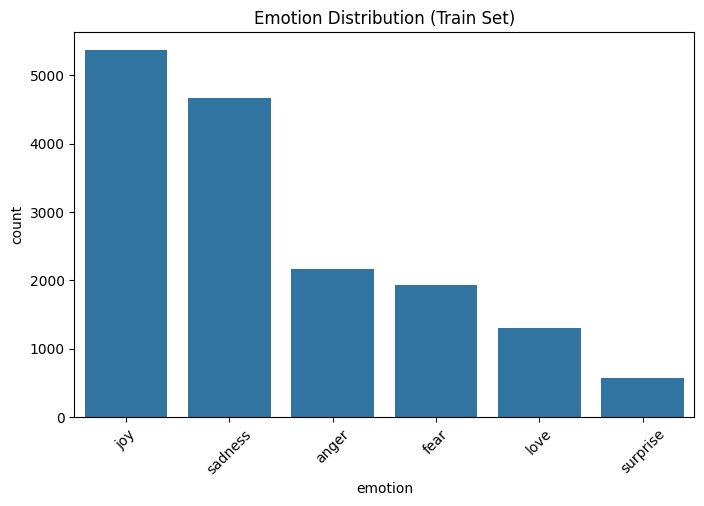

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print(train_df['emotion'].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=train_df, x='emotion', order=train_df['emotion'].value_counts().index)
plt.title("Emotion Distribution (Train Set)")
plt.xticks(rotation=45)
plt.show()

 5: **Text Preprocessing**

    Cleaning the text by converting to lowercase, removing special characters, and removing stopwords.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

train_df['clean_text'] = train_df['text'].apply(clean_text)
val_df['clean_text']   = val_df['text'].apply(clean_text)
test_df['clean_text']  = test_df['text'].apply(clean_text)

train_df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,text,emotion,clean_text
0,i didnt feel humiliated,sadness,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,anger,feeling grouchy


6. **Label Encoding**

    
       Converting emotion labels from text to numeric values for model training.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['emotion'])
val_df['label']    = le.transform(val_df['emotion'])
test_df['label']   = le.transform(test_df['emotion'])

num_classes = len(le.classes_)
print("Classes:", le.classes_)

Classes: ['anger' 'fear' 'joy' 'love' 'sadness' 'surprise']


7: **Tokenization and Padding**

    Converting cleaned text into padded integer sequences suitable for the model.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 10000
max_len = 50
oov_token = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(train_df['clean_text'])

X_train = pad_sequences(tokenizer.texts_to_sequences(train_df['clean_text']), maxlen=max_len, padding='post')
X_val   = pad_sequences(tokenizer.texts_to_sequences(val_df['clean_text']), maxlen=max_len, padding='post')
X_test  = pad_sequences(tokenizer.texts_to_sequences(test_df['clean_text']), maxlen=max_len, padding='post')

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

print(X_train.shape, X_val.shape, X_test.shape)

(16000, 50) (2000, 50) (2000, 50)


8. **Model Architecture**

         Building a Bidirectional LSTM model with dropout layers for regularization.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, Input

embedding_dim = 100

model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 100)        │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,130,246 (4.31 MB)

 Trainable params: 1,130,246 (4.31 MB)

 Non-trainable params: 0 (0.00 B)

9. **Model Training**
  
        Training the model with class weights to address class imbalance in the dataset.

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

Class weights: {0: np.float64(1.2351397251814111), 1: np.float64(1.3766993632765445), 2: np.float64(0.49732686808404825), 3: np.float64(2.044989775051125), 4: np.float64(0.5715102157451064), 5: np.float64(4.662004662004662)}
Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 104ms/step - accuracy: 0.9548 - loss: 0.1603 - val_accuracy: 0.9060 - val_loss: 0.3145
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 84s 109ms/step - accuracy: 0.9682 - loss: 0.1017 - val_accuracy: 0.9120 - val_loss: 0.3398
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 107ms/step - accuracy: 0.9763 - loss: 0.0765 - val_accuracy: 0.9060 - val_loss: 0.3686
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 106ms/step - accuracy: 0.9797 - loss: 0.0622 - val_accuracy: 0.9065 - val_loss: 0.4236


10. **Model Evaluation**
   
        Evaluating performance using test accuracy, a classification report, and a confusion matrix.

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9010 - loss: 0.3543
Test Accuracy: 0.9010
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
              precision    recall  f1-score   support

       anger       0.90      0.89      0.90       275
        fear       0.91      0.83      0.86       224
         joy       0.96      0.90      0.93       695
        love       0.69      0.89      0.77       159
     sadness       0.96      0.94      0.95       581
    surprise       0.61      0.85      0.71        66

    accuracy                           0.90      2000
   macro avg       0.84      0.88      0.85      2000
weighted avg       0.91      0.90      0.90      2000



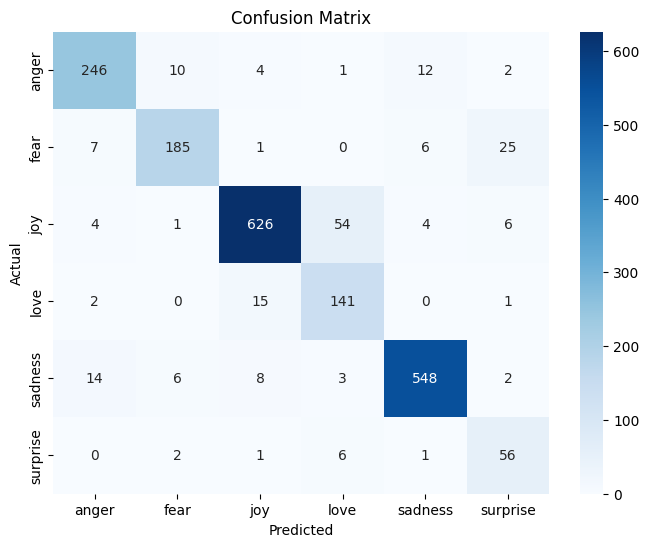

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

11. **Training Performanc Curves**
     
      
        Plotting accuracy and loss over epochs to check for overfitting/underfitting.

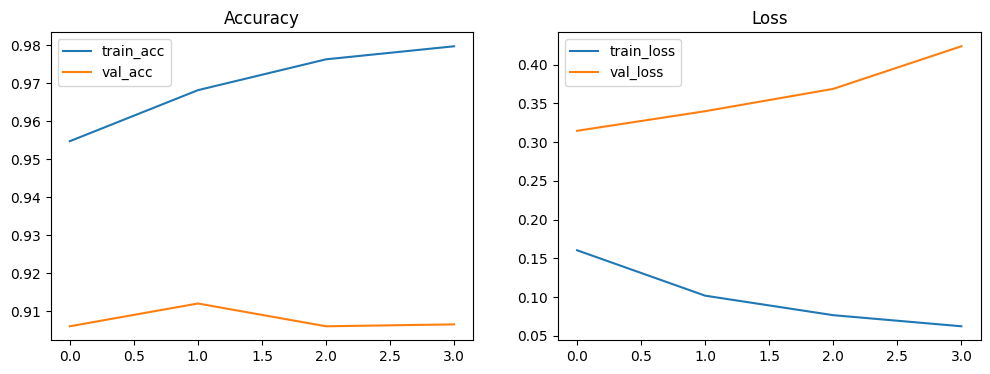

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(); plt.title("Loss")

plt.show()

12. **Predictions on New Sentences**

      
        Trying the model on new, unseen sentences to see real-world predictions.

In [ ]:
def predict_emotion(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')
    pred = model.predict(padded)
    label = le.inverse_transform([np.argmax(pred)])
    return label[0]

print(predict_emotion("I am so happy today, everything is going great!"))
print(predict_emotion("I feel so anxious about the exam tomorrow."))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
joy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
fear


 13. **Save the Model**

         Saving the trained model, tokenizer, and label encoder for future use without retraining.

In [ ]:
model.save('/content/emotion_model.h5')
print("Model saved!")

import pickle
with open('/content/tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('/content/label_encoder.pickle', 'wb') as handle:
    pickle.dump(le, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Tokenizer and label encoder saved!")

Model saved!
Tokenizer and label encoder saved!


In [ ]:
from google.colab import files

files.download('/content/emotion_model.h5')
files.download('/content/tokenizer.pickle')
files.download('/content/label_encoder.pickle')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>